IMPORTING THE DEPENDENCIES

In [ ]:
!pip install -q scikit-learn==1.9.1

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

DATA COLLECTION AND PROCESSING

In [ ]:
heart_data = pd.read_csv("/content/Heart_report.csv")

In [ ]:
heart_data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
heart_data.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [ ]:
heart_data.shape

(918, 12)

In [ ]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


HANDLING MISSING VALUES

In [ ]:
heart_data.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [ ]:
heart_data_copy = heart_data

In [ ]:
numerical_cols = heart_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = heart_data.select_dtypes(include=['object', 'category']).columns.tolist()

CHECK FOR DUPLICATE ROWS

In [ ]:
heart_data.duplicated().sum()

np.int64(0)

In [ ]:
for col in heart_data.columns:
  print(f"\n{col}: ")
  print(heart_data[col].unique())


Age: 
[40 49 37 48 54 39 45 58 42 38 43 60 36 44 53 52 51 56 41 32 65 35 59 50
 47 31 46 57 55 63 66 34 33 61 29 62 28 30 74 68 72 64 69 67 73 70 77 75
 76 71]

Sex: 
['M' 'F']

ChestPainType: 
['ATA' 'NAP' 'ASY' 'TA']

RestingBP: 
[140 160 130 138 150 120 110 136 115 100 124 113 125 145 112 132 118 170
 142 190 135 180 108 155 128 106  92 200 122  98 105 133  95  80 137 185
 165 126 152 116   0 144 154 134 104 139 131 141 178 146 158 123 102  96
 143 172 156 114 127 101 174  94 148 117 192 129 164]

Cholesterol: 
[289 180 283 214 195 339 237 208 207 284 211 164 204 234 273 196 201 248
 267 223 184 288 215 209 260 468 188 518 167 224 172 186 254 306 250 177
 227 230 294 264 259 175 318 216 340 233 205 245 194 270 213 365 342 253
 277 202 297 225 246 412 265 182 218 268 163 529 100 206 238 139 263 291
 229 307 210 329 147  85 269 275 179 392 466 129 241 255 276 282 338 160
 156 272 240 393 161 228 292 388 166 247 331 341 243 279 198 249 168 603
 159 190 185 290 212 231 222 235 320 187 

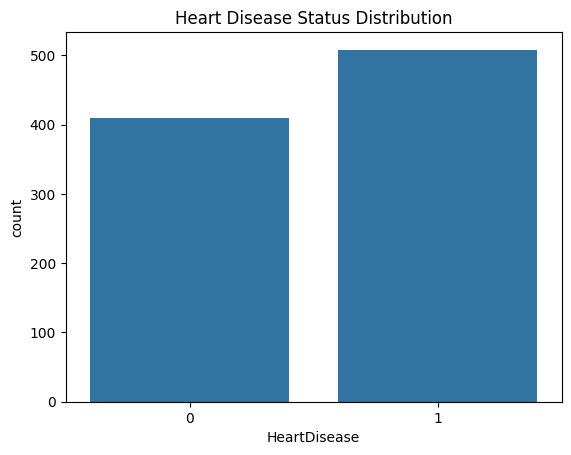

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='HeartDisease', data=heart_data)
plt.title('Heart Disease Status Distribution')
plt.show()

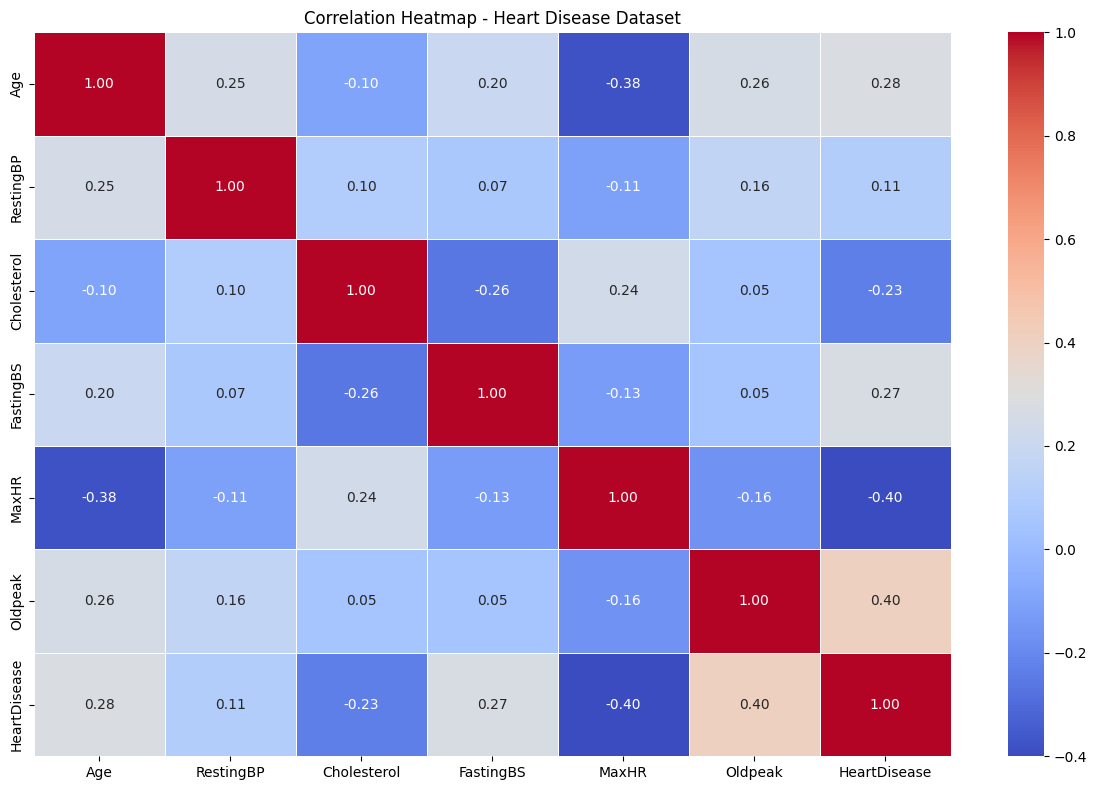

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix
corr_matrix = heart_data.corr(numeric_only=True)

# Heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap - Heart Disease Dataset')
plt.tight_layout()
plt.show()

ENCODING CATEGORICAL COLUMNS AND SCALING NUMERICAL COLUMNS

In [ ]:
heart_data.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ohe = OneHotEncoder(sparse_output = False, handle_unknown = "ignore")
encoded = ohe.fit_transform(heart_data[categorical_cols])
encoded_df = pd.DataFrame(encoded ,columns=ohe.get_feature_names_out(categorical_cols),index = heart_data.index)
heart_data = pd.concat([heart_data.drop(columns=categorical_cols), encoded_df], axis = 1)

In [ ]:
X = heart_data.drop("HeartDisease", axis=1)
y = heart_data['HeartDisease']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

ML MODEL TRAINING

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    )
}

In [ ]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Gradient Boosting trained successfully.
SVM trained successfully.


/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [ ]:
results = []

for name, model in models.items():

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df.round(4)

,Model,Accuracy,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8859,0.9314,0.9005,0.9295
1,Decision Tree,0.7935,0.8137,0.8137,0.7910
2,Gradient Boosting,0.8913,0.9020,0.9020,0.9305
3,SVM,0.8859,0.9314,0.9005,0.9420


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

import pandas as pd

In [ ]:
# Identify columns
numerical_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()


# Numerical preprocessing
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


# Categorical preprocessing
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


# Combined preprocessing
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=[
            'accuracy',
            'precision',
            'recall',
            'f1',
            'roc_auc'
        ],
        n_jobs=-1
    )

    cv_results.append({
        'Model': name,
        'CV Accuracy': scores['test_accuracy'].mean(),
        'CV Precision': scores['test_precision'].mean(),
        'CV Recall': scores['test_recall'].mean(),
        'CV F1-Score': scores['test_f1'].mean(),
        'CV ROC-AUC': scores['test_roc_auc'].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.round(4)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1-Score,CV ROC-AUC
0,Logistic Regression,0.8649,0.8686,0.8938,0.8802,0.9247
1,Decision Tree,0.7690,0.8086,0.7678,0.7865,0.7693
2,Gradient Boosting,0.8638,0.8628,0.8997,0.8801,0.9222
3,SVM,0.8584,0.8542,0.8997,0.8756,0.9167


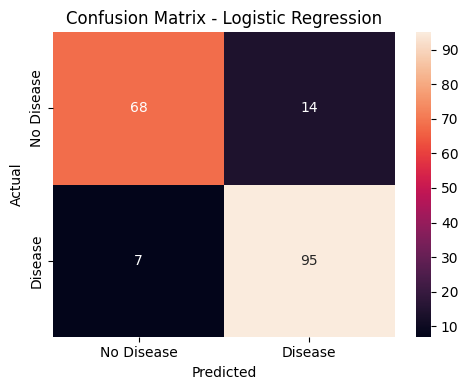

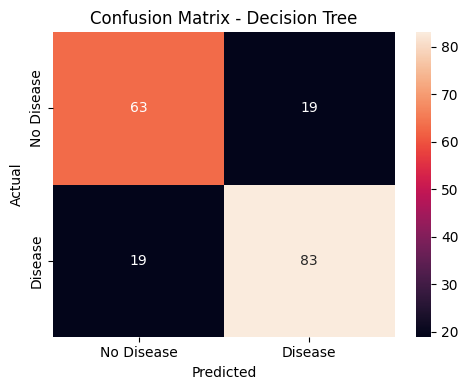

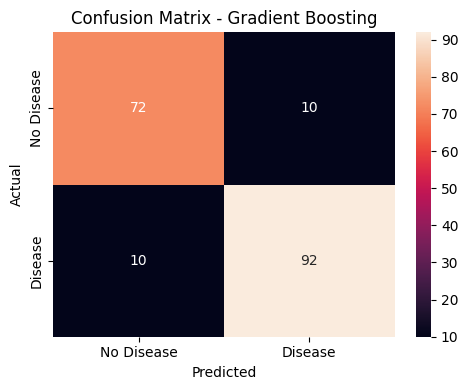

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


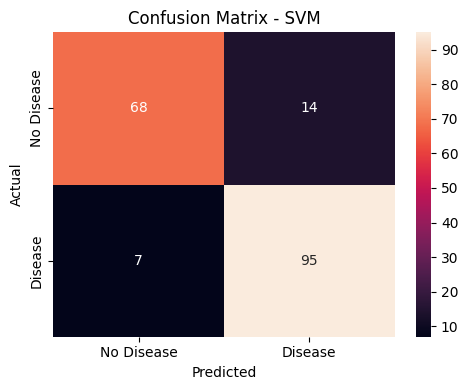

In [ ]:
for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        xticklabels=['No Disease', 'Disease'],
        yticklabels=['No Disease', 'Disease']
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

In [ ]:
final_model = GradientBoostingClassifier(
    random_state=42
)

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', final_model)
])

In [ ]:
final_pipeline.fit(X_train, y_train)

print("Final Gradient Boosting model trained successfully!")

Final Gradient Boosting model trained successfully!


In [ ]:
import joblib

joblib.dump(
    final_pipeline,
    'heart_disease_model.pkl'
)

print("Model saved as heart_disease_model.pkl")

Model saved as heart_disease_model.pkl


In [ ]:
loaded_model = joblib.load('heart_disease_model.pkl')

sample_predictions = loaded_model.predict(X_test.head(5))

print("Predictions:", sample_predictions)

Predictions: [1 1 1 0 0]
